# LKIPA Time Series Data Collection

In this notebook we develop the script to collect time series data from the JPA. 

- PUMP OFF
- PUMP ON (Sub-Threshold)
- PUMP ON (Threshold)
- PUMP ON (Super-Threshold)

PUMP OFF data is required to quantify the background noise level and frequency spectrum to subtract from the PUMP ON cases. 

----

*Post Attempt Remarks*: 
1. The dc bias and pump signals do no persist after exiting the lockin mode instance, so this strategy will not work. 
2. We can directly add dc bias using ```tst.hardware.st_dc_bias```

In [1]:
# IMPORTS
# =======
import os
import sys

import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np
from tqdm import tqdm

from presto import test
from presto import lockin, utils
from presto.hardware import AdcMode, DacMode, AdcFSample, DacFSample

## 1. PRESTO Configuration

In [ ]:
# Network settings for Presto Hardware
ADDRESS = '130.237.35.90'       # IP Address
PORT    = 42873                 # TCP Port

# Input (ADC) settings
INPUT_PORT = 5                  # Correlated vacuum input to presto, output frm JPA
ADC_ATT = 0.0                   # dB, 0.0 to 27.0
INPUT_NCO = 0                   # Hz, 0 to 10 GHz
DF = 0.1e6                      # MHz

# FLUX PUMP Output (DAC) settings
FLUX_PORT = 2                   # Pump frequency comb output from presto, input to JPA
PUMP_AMP = 0.25                 # amplitude of pump signal, 0 for vacuum
PHASEI = 0.0                    # rad
PHASEQ = PHASEI - np.pi / 2     # rad
f0= 4.44277e9                   # Resonance Frequency (Hz)  4427780358
PUMP_NCO = 8.84e9               # NCO frequency for pump set to 8.4 GHz
PUMP_FREQ = 2 * f0 - PUMP_NCO   # Hz, 0 to 500 MHz, intermediate frequency

# DC BIAS settings
DC_PORT = 2                     # DC Bias for optimal operating point of JPA   
DAC_CURR = 32_000               # μA, 2250 to 40500   
DC_BIAS = 0.5                   # Set JPA Resonance to 4.2 GHz, taken from latest calibration

# Converter configuration for Presto hardware
CONVERTER_CONFIGURATION = {
    "adc_mode": AdcMode.Direct,
    "adc_fsample": AdcFSample.G2,
    "dac_mode": DacMode.Mixed02,
    "dac_fsample": DacFSample.G6,
}     

# Number of pixels to be captured
N_PIX = 5_000             

## 2. Data Acquisition Loop

In [ ]:
# Define data acquisition function
def data_acquisition(
    address: str,
    port: int,
    converter_configuration: dict,
    input_port: int,
    adc_att: float,
    input_nco: float,
    output_port: int,
    dac_curr: int,
    amp: float,
    freq: float,
    phasei: float,
    phaseq: float,
    output_nco: float,
    df: float,
    dcb_port: int,fig.savefig(
    fname= f'Figures/Scattering/LKIPA-Scat-modes={modes}-df={df}-dcb=05-pump_amp={p_amp}-pump_freq={fp}-run={run}', 
    dpi=300,
    )
    dcb_amp: float,
    n_pix: int
):
    with test.Test(address=address, port=port, **converter_configuration) as tst:
        # Get extra samples at the beginning and throw them away
        extra = 1000
        # Calculate number of samples from DF
        nr_samples = int(round(tst.get_fs("adc") / df))

        # Configure mixers for input and output ports
        tst.hardware.configure_mixer(input_nco, in_ports=input_port, sync=False)
        tst.hardware.configure_mixer(output_nco, out_ports=output_port, sync=True)

        # Configure ADC and DAC settings
        tst.hardware.set_adc_attenuation(input_port, adc_att)
        tst.hardware.set_dac_current(output_port, dac_curr)
        
        # Set DC bias for 4.2GHz operating point of JPA
        tst.hardware.set_dc_bias(port=dcb_port, bias=dcb_amp)
        tst.hardware.sleep(1e-4)

        # Configure output signal for pump tone
        tst.set_frequency(output_port, freq)
        tst.set_phase(output_port, phasei, phaseq)
        tst.set_scale(output_port, scale_i = amp, scale_q = amp)
        tst.hardware.sleep(1e-4)

        # Print hardware configuration statement
        print('Hardware configuration successful, initiating data acquisition ...')

        # Start data acquisition
        data_all = []
        with tqdm(total=n_pix, ncols=80) as pbar:
            for i in range(n_pix):
                tst.hardware.set_run(False)
                tst.set_dma_source(input_port)
                tst.start_dma(extra + nr_samples)
                tst.hardware.set_run(True)
                tst.wait_for_dma()
                tst.stop_dma()
                data = tst.get_dma_data(extra + nr_samples)
                tst.hardware.check_adc_intr_status()
                
                # Throw away initial `extra` data points, convert to FS
                if converter_configuration["adc_mode"] == AdcMode.Mixed:
                    data = data[2*extra:] / 32767

                elif converter_configuration["adc_mode"] == AdcMode.Direct:
                    data = data[extra:] / 32767

                # Append to data_all list
                data_all.append(data)
                
                # Update progress bar
                pbar.update(1)

        # set all outputs to 0
        tst.hardware.set_dc_bias(port=dcb_port, bias=0.0)
        tst.set_scale(output_port, scale_i = 0, scale_q = 0)
        
        # convert data list to np.array
        data_all = np.array(data_all)

        # Measurement metadata
        dt = tst.get_dt("adc")*1e9
        fs = tst.get_fs("adc")*1e-9

        # Print completion statement
        print('Data Acquisition Complete.')
    
    return data_all, dt, fs, nr_samples

In [99]:
data_all, dt, fs, n_samples = data_acquisition(
            address=ADDRESS,
            port=PORT,
            converter_configuration=CONVERTER_CONFIGURATION,
            input_port=INPUT_PORT,
            adc_att=ADC_ATT,
            input_nco=INPUT_NCO,
            output_port=FLUX_PORT,
            dac_curr=DAC_CURR,
            amp=PUMP_AMP,
            freq=PUMP_FREQ,
            phasei=PHASEI,
            phaseq=PHASEQ,
            output_nco=PUMP_NCO,
            df=DF,
            dcb_port=DC_PORT,
            dcb_amp=DC_BIAS,
            n_pix=N_PIX
        )

# Print measurement metadata
# ==========================

print('MEASUREMENT PARAMETERS:')
print('=======================')

# Analog-to-Digital Converter Mode
print(f'Mode: {CONVERTER_CONFIGURATION["adc_mode"]}')

# Number of pixels captured
print(f"Number of pixels: {N_PIX}")

# Pixel duration
print(f"Pixel time resolution (dt): {dt:.2f} ns")

# Sampling frequency of the ADC (GHz)
print(f"Sampling frequency (fs): {fs:.2f} GHz")

t_meas = 1e6 / DF # Measurement time per pixel (μs)
print(f"Total measurement time: {t_meas:.1f} µs")

# Frequency resolution (kHz)
print(f"Frequency resolution (DF): {DF/1e3:.1f} kHz")

# Data points captured per pixel
N_datastream = np.shape(data_all)[1]
print(f"Data points captured per pixel: {N_datastream}")

# Number of samples per pixel 
print(f"Number of samples per pixel: {n_samples}")

Hardware configuration successful, initiating data acquisition ...


100%|███████████████████████████████████████| 5000/5000 [01:23<00:00, 59.90it/s]


Data Acquisition Complete.
MEASUREMENT PARAMETERS:
Mode: AdcMode.Direct
Number of pixels: 5000
Pixel time resolution (dt): 0.50 ns
Sampling frequency (fs): 2.00 GHz
Total measurement time: 10.0 µs
Frequency resolution (DF): 100.0 kHz
Data points captured per pixel: 20000
Number of samples per pixel: 20000


## 2.1 Extract time series data based on `AdcMode` 

In [100]:
if CONVERTER_CONFIGURATION["adc_mode"] == AdcMode.Mixed:
    print("Data format: Mixed mode (I and Q interleaved)")

    # Convert raw ADC data to full-scale (FS) units and separate I and Q components
    I_all = data_all[:, 0::2]
    Q_all = data_all[:, 1::2]
    print(f"Shape of I data: {I_all.shape}")

    # Assign data array for raw pixel I data
    for pix in range(N_PIX):
        I_all[pix]= I_all[pix] - np.mean(I_all[pix])  # remove DC component
    
elif CONVERTER_CONFIGURATION["adc_mode"] == AdcMode.Direct:
    print("Data format: Direct mode (I only)")

    # Convert raw ADC data to full-scale (FS) units
    I_all = data_all
    print(f"Shape of I data: {I_all.shape}")

    for pix in range(N_PIX):
        I_all[pix]= I_all[pix] - np.mean(I_all[pix])  # remove DC component

Data format: Direct mode (I only)
Shape of I data: (5000, 20000)


## 3. Time Series and FFT Plot

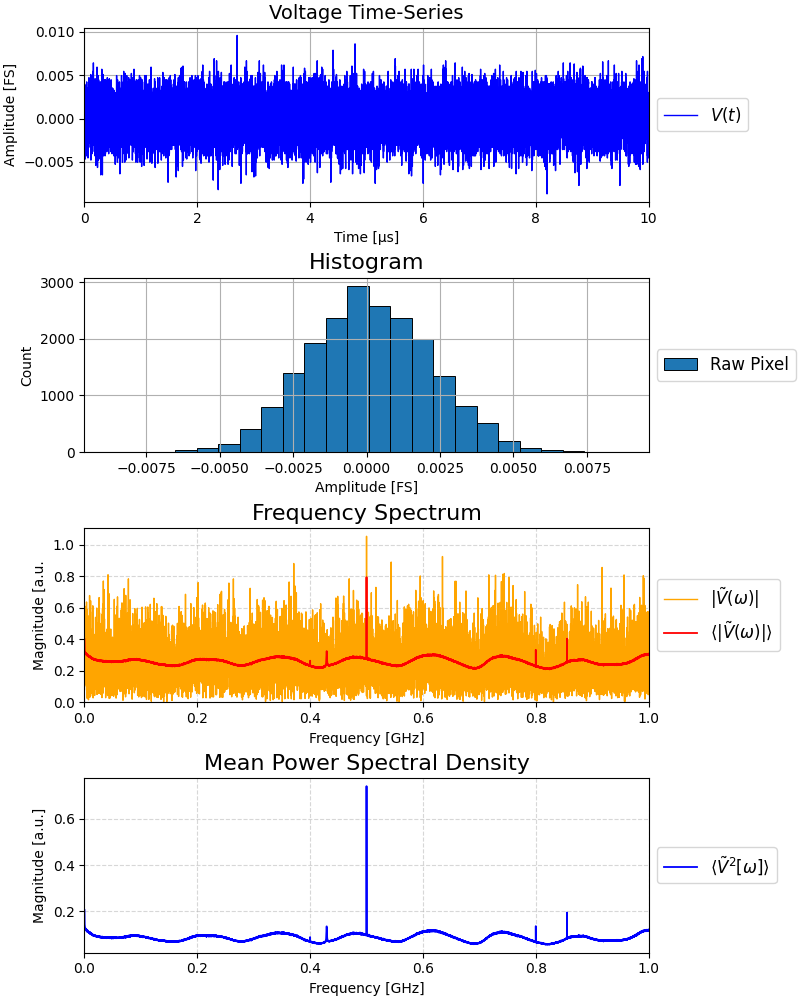

In [101]:
t_arr = dt * np.linspace(0, n_samples, n_samples, endpoint=False) * 1e-3    # μs, convert from seconds

# Example time series
raw = 50
data_raw = I_all[raw]

# FFT
# ===

# frequency array for FFT
f_arr = np.fft.rfftfreq(n_samples, dt)  # Hz

fft_data_list = [] #np.zeros((N_PIX, n_samples))
for pix in range(N_PIX):
    fft_data_list.append(np.fft.rfft(I_all[pix]))

# FFT of all time series
fft_data_list = np.array(fft_data_list)

# Example |FFT|
fft_raw = fft_data_list[raw]               # Real FFT of single pixel data

# Pixel Averaged |FFT|
fft_avg = np.mean(np.abs(fft_data_list), axis=0)    # FFT averaged over all pixels

# PSD 
# ===

# Mean PSD
PSD_avg = np.mean(np.abs(fft_data_list)  ** 2, axis = 0)   # PSD averaged over all pixels

# Save pump OFF averaged PSD for subtracting out background noise
_df = int(DF/1e6)
if PUMP_FREQ== 0:
    np.savetxt(
        fname=f'Time series data/LKIPA-PSD-df={_df}Mhz-pixels={N_PIX}.txt',
        X= PSD_avg,
        delimiter=','
        )

# PLOT
# ====
fig, ax = plt.subplots(
    nrows=4,                    
    ncols=1,
    constrained_layout=True, 
    figsize=(8, 10)
    )

ax1, ax2, ax3, ax4 = ax

# Plot pixel averaged and single pixel data together in the first subplot
ax1.plot(t_arr, data_raw, label="$V(t)$", color='b', lw=1)
ax1.set_xlabel("Time [μs]")
ax1.set_ylabel("Amplitude [FS]")
ax1.set_title("Voltage Time-Series", fontsize=14)
ax1.set_xlim(0, t_meas)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
ax1.grid()

# Plot histogram of the data in the second subplot
ax2.hist(data_raw, bins=25, label="Raw Pixel", edgecolor='black', lw=0.7)
ax2.set_xlabel("Amplitude [FS]")
ax2.set_ylabel("Count")
ax2.set_title("Histogram", fontsize=16)
ax2.set_xlim(-np.max(np.abs(data_raw)), np.max(np.abs(data_raw)))
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
ax2.grid()

# Plot FFT
ax3.grid(alpha=0.5, linestyle='--')
ax3.plot(f_arr[1:-1], np.abs(fft_raw[1:-1]), label='$|\\tilde V(\\omega)|$', color='orange', lw=1)
ax3.plot(f_arr[1:-1], fft_avg[1:-1], label='$\\langle |\\tilde V(\\omega)| \\rangle$', color='red', lw=1.3)
ax3.set_xlabel("Frequency [GHz]")
ax3.set_ylabel("Magnitude [a.u.")
ax3.set_xlim(0, fs/2)
ax3.set_ylim(ymin=0)
ax3.set_title("Frequency Spectrum", fontsize=16)
ax3.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

# Plot PSD
ax4.grid(alpha=0.5, linestyle='--')
ax4.plot(f_arr[1:-1], PSD_avg[1:-1], label="$\\langle \\tilde V^2[\\omega] \\rangle$", color = "b", lw=1.3)
ax4.set_xlabel("Frequency [GHz]")
ax4.set_ylabel("Magnitude [a.u.]")
ax4.set_xlim(0, fs/2)
ax4.set_title("Mean Power Spectral Density", fontsize=16)
ax4.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)


#fig.suptitle("Signal Analysis", fontsize=20)
plt.show()

## 3.1 Shift in Power Spectral Density

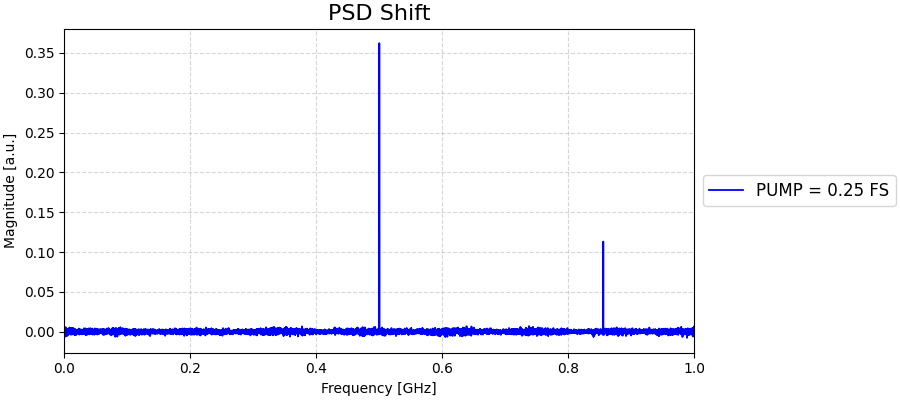

In [102]:
# Load PUMP OFF pixel averaged |FFT| into numpy array for comparison with PUMP ON cases

PSD_avg_PUMP_OFF = np.loadtxt(
    fname=f'Time series data/LKIPA-PSD-df={_df}Mhz-pixels={N_PIX}.txt',
    delimiter=','
)

fig31, ax31 = plt.subplots(figsize= (9, 4), constrained_layout = True)

ax31.grid(alpha=0.5, linestyle='--')
ax31.plot(f_arr[1:-1], PSD_avg[1:-1] - PSD_avg_PUMP_OFF[1:-1], label=f"PUMP = {PUMP_AMP} FS", color = "b", lw=1.3)
ax31.set_xlabel("Frequency [GHz]")
ax31.set_ylabel("Magnitude [a.u.]")
ax31.set_xlim(0, fs/2)
#ax31.set_ylim(-0.01, 0.06)
ax31.set_title("PSD Shift", fontsize=16)
ax31.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

# SAVE FIGURE
p = int(10 * PUMP_AMP)
if p!=0:
    fig31.savefig(
        fname=f'Figures/JPA PSD Shift p0{p} mar3'
    )

## 4. 1-Time Autocorrelation


The 1-time auto-correlation function $\mathfrak{A}(\tau)$ for a discrete voltage time signal $I(t)$ over the time window $t \in [t_i, t_i + dt, \dots, t_f]$ is given by:

$$
\begin{aligned}
    \mathfrak{A}(\tau) &= \braket{ I(t) \cdot I(t - \tau) }_{t} \\
    &= \frac{1}{t_i - t_f}\sum^{t_f}_{t_i} I(t) \cdot I(t - \tau)
\end{aligned}
$$

Additionally, we can pixel average $\mathfrak{A}(\tau)$ to enhance the SNR.

In [103]:
# Define time window for autocorrelation
window_size = 3
n_midpoint = n_samples // 2
t_i_idx = n_midpoint - n_samples // window_size
t_f_idx = n_midpoint + n_samples // window_size

# Single element in sum expression for autocorrelation 
def autocorr_tau(I_data, t_i_idx, t_f_idx, tau, dt):
    tau_idx = int(tau // dt)
    autocorr = np.zeros(t_f_idx - t_i_idx, dtype=np.float64)

    for t_idx in range(t_f_idx - t_i_idx):
        autocorr[t_idx] = I_data[t_i_idx + t_idx] * I_data[t_i_idx + t_idx - tau_idx]
    return np.mean(autocorr)

# Total autocorrelation function summed over window
def autocorr_1time(I_data, t_i_idx, t_f_idx, tau_set, dt):
    autocorr = np.zeros(len(tau_set), dtype=np.float64)
    for i, tau in enumerate(tau_set):
        autocorr[i] = autocorr_tau(I_data, t_i_idx, t_f_idx, tau, dt)
    return autocorr

def autocorr_1time_pix_avg(I_data, t_i_idx, t_f_idx, tau_set, dt, n_pix):
    autocorr_avg = []
    with tqdm(total=n_pix, ncols=80) as pbar:
        for pix in range(n_pix):
            autocorr_avg.append(
                autocorr_1time(
                    I_data[pix],
                    t_i_idx,
                    t_f_idx, 
                    tau_set,
                    dt
                    )
                    )
            pbar.update(1)
    return np.mean(autocorr_avg, axis=0)

tau_set = (t_arr[70:130] - t_meas/2) * 1e3 # μs, convert from seconds
# autocorr_1time_ts = autocorr_1time_pix_avg(
#     I_all, 
#     t_i_idx, 
#     t_f_idx, 
#     tau_set, 
#     dt,
#     N_PIX)

#Save PUMP OFF autocorrelation trace to subtract from PUMP ON case
# if p==0:
#     np.savetxt(
#         fname=f'JPA_autocorr_PUMP_OFF_df{_df}_dcb{int(10*DC_BIAS)}',
#         X=autocorr_1time_ts,
#         delimiter="," 
#         )
#     print('Saved autocorrelation time series for df = ', _df, 'MHz')

## 4.1.1 Plot Autocorrelation

In [104]:
# LOAD PUMP OFF autocorrelation trace to subtract from PUMP ON case
# autocorr_1time_PUMP_OFF = np.loadtxt(
#     fname=f'JPA_autocorr_PUMP_OFF_df{_df}',
#     delimiter="," 
#     )

# Predicted autocorrelation from mean PSD
autocorr_predicted = np.fft.irfft(PSD_avg)
autocorr_predicted = np.concatenate(
    (autocorr_predicted[n_samples//2:], autocorr_predicted[0:n_samples//2])
) * np.max(autocorr_1time_ts)/np.max(autocorr_predicted)


# autocorr_predicted_PUMP_OFF = np.fft.irfft(PSD_avg_PUMP_OFF)
# autocorr_predicted_PUMP_OFF_untwist = np.concatenate(
#     (autocorr_predicted_PUMP_OFF[n_samples//2:], autocorr_predicted_PUMP_OFF[0:n_samples//2])
# ) * np.max(autocorr_1time_ts)/np.max(autocorr_predicted)

#autocorr_predicted_shift = autocorr_predicted_untwist - autocorr_predicted_PUMP_OFF_untwist

# Save trace of autocorrelation shift for p = 0.5, 0.4, 0.3, etc.
#if p!=0 :
# autocorr_1time_shift = autocorr_1time_ts - autocorr_1time_PUMP_OFF
# np.savetxt(
#     fname=f'JPA_autocorr_shift_p0{p}_30ns_50k_pixels',
#     X=autocorr_1time_shift,
#     delimiter=','
# )

fig, ax = plt.subplots(figsize=(8, 5), tight_layout=True)
ax.plot(
    tau_set,
    np.abs(autocorr_predicted[70:130]),
    label='FFT of PSD Shift',
    lw=0.8
)
# ax.axvline(x = -2.5, lw=0.8, ls='--', color = 'r', label='$\\Delta t = 2.5$ns')
# ax.axvline(x = +2.5, lw=0.8, ls='--', color = 'r')
# ax.axvline(x = -5.0, lw=0.8, ls='--', color = 'r')
# ax.axvline(x = +5.0, lw=0.8, ls='--', color = 'r')
# ax.axvline(x = -7.5, lw=0.8, ls='--', color = 'r')
# ax.axvline(x = +7.5, lw=0.8, ls='--', color = 'r')
# ax.plot(
#     tau_set, 
#     np.abs(autocorr_1time_ts), 
#     label="$\\Delta \\mathfrak{A}(\\tau)$ : " + f"0.{PUMP_AMP} FS",
#     lw=1.5
#     )

ax.set_xlabel("$\\tau$ [ns]", fontsize=14)
ax.set_ylabel("Autocorrelation [FS$^2$]", fontsize=14)
ax.set_title("Shift in Autocorrelation", fontsize=16)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
ax.grid()
plt.show()

# if p==0 :
#     fig, ax = plt.subplots(figsize=(7, 5), tight_layout=True)
#     ax.plot(
#         tau_set, 
#         (autocorr_1time_PUMP_OFF), 
#         label="$\\mathfrak{A}(\\tau)$" 
#         )
#     ax.plot(
#         tau_set,
#         autocorr_predicted_untwist[70:130],
#         label='From PSD'
#     )
#     ax.set_xlabel("$\\tau$ [ns]", fontsize=14)
#     ax.set_ylabel("Autocorrelation [FS$^2$]", fontsize=14)
#     ax.set_title("Vacuum Autocorrelation (PUMP OFF)", fontsize=16)
#     ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
#     ax.grid()
#     plt.show()

NameError: name 'autocorr_1time_ts' is not defined